# Empirical-Bayes enrichment — 3-seed 확정 검증

## 목적
seed 42 screen에서 통과한 **고정 Empirical-Bayes gene×event-type enrichment**가 분할 운이 아닌지 `42 / 777 / 2024`에서 확인한다.

## 고정 계약
- 후보: 기존 `eb` 축만 실행 — gene×event-type token, Beta-Binomial posterior log-odds (`alpha=1`, `prior-strength=20`, `clip=±4`)
- 모델: Logistic Regression `lbfgs`, `C=0.07`, `max_iter=2000`, `class_weight='balanced'`
- 검증: seed별 Stratified 5-fold; baseline과 후보가 **같은 fold**를 공유
- 금지: 새 피처, smoothing, blend 비율, threshold의 추가 탐색
- 누수 계약: supervised enrichment·정규화는 fold-train/inner-fold-train에서만 fit하며, test는 읽거나 통계에 사용하지 않음
- NaN 계약: NaN은 mutation event가 아니며 `nan_as_mutation_count == 0`을 assert

## 채택 기준
세 seed 모두 P1 기준선보다 상승하고, 평균 paired delta가 변동보다 크며, 수렴 경고 0·`leakage_check=True`·NaN mutation 0을 만족할 때만 채택한다.


In [1]:
from pathlib import Path
import subprocess
import sys

from tqdm.auto import tqdm

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py').exists())
COMMON = ROOT / 'experiments/gs/notebooks/exp_model_002/common'
RUNNER = COMMON / 'run_p1_axis.py'
RESULT = RUNNER.parent.parent / 'result'

RUN_ID = 'exp-empirical-bayes-enrichment-02'
SEEDS = (42, 777, 2024)
RUN_EXPERIMENT = True  # 결과만 다시 집계하려면 False

assert RUNNER.exists(), RUNNER
print({'runner': RUNNER, 'result_dir': RESULT, 'seeds': SEEDS, 'axis': 'eb'})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_002/result'), 'seeds': (42, 777, 2024), 'axis': 'eb'}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 각 seed는 독립 프로세스로 실행한다. 실패하면 마지막 로그를 그대로 표시해 원인을 확인할 수 있다.
if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS, desc='Empirical-Bayes 3-seed confirmation'):
        cmd = [sys.executable, str(RUNNER), '--axis', 'eb', '--seed', str(seed), '--run-id', RUN_ID]
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
        tail = []
        assert process.stdout is not None
        for line in process.stdout:
            print(f'[seed={seed}] {line}', end='')
            tail = (tail + [line])[-120:]
        return_code = process.wait()
        if return_code:
            raise RuntimeError(
                f'Empirical-Bayes confirmation failed (seed={seed}, exit={return_code}). '
                'Last runner output:\n' + ''.join(tail)
            )
else:
    print('RUN_EXPERIMENT=False: 기존 seed 결과만 집계합니다.')


Empirical-Bayes 3-seed confirmation:   0%|          | 0/3 [00:00<?, ?it/s]

[seed=42] 
[seed=42] row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 392.05it/s]
[seed=42]           variant  oof_macro_f1  feature_count  convergence_warning_count  leakage_check  nan_as_mutation_count  runtime_seconds
[seed=42] P1 multinomial LR      0.527550         8201.2                          0           True                      0        78.847156
[seed=42]                eb      0.533955         8201.2                          0           True                      0        78.855133


Empirical-Bayes 3-seed confirmation:  33%|███▎      | 1/3 [01:38<03:16, 98.17s/it]

[seed=777] 
[seed=777] row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 385.84it/s]
[seed=777]           variant  oof_macro_f1  feature_count  convergence_warning_count  leakage_check  nan_as_mutation_count  runtime_seconds
[seed=777] P1 multinomial LR      0.526006         8196.4                          0           True                      0        79.935448
[seed=777]                eb      0.535289         8196.4                          0           True                      0        79.943921


Empirical-Bayes 3-seed confirmation:  67%|██████▋   | 2/3 [03:17<01:38, 98.64s/it]

[seed=2024] 
[seed=2024] row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 390.47it/s]
[seed=2024]           variant  oof_macro_f1  feature_count  convergence_warning_count  leakage_check  nan_as_mutation_count  runtime_seconds
[seed=2024] P1 multinomial LR      0.525111         8201.0                          0           True                      0        78.130180
[seed=2024]                eb      0.531975         8201.0                          0           True                      0        78.137908


Empirical-Bayes 3-seed confirmation: 100%|██████████| 3/3 [04:54<00:00, 98.06s/it]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(COMMON))
from eb_confirmation import summarize_three_seed, P1_VARIANT, EB_VARIANT

frames = []
for seed in SEEDS:
    path = RESULT / f'{RUN_ID}_seed{seed}_summary.csv'
    assert path.exists(), f'결과 파일이 없습니다: {path}'
    one = pd.read_csv(path)
    one['seed'] = seed
    assert one.leakage_check.all(), f'leakage_check failed: seed={seed}'
    assert one.nan_as_mutation_count.eq(0).all(), f'NaN mutation detected: seed={seed}'
    assert one.convergence_warning_count.eq(0).all(), f'convergence warning: seed={seed}'
    frames.append(one)

raw = pd.concat(frames, ignore_index=True)
per_seed, aggregate = summarize_three_seed(raw)

per_seed_path = RESULT / f'{RUN_ID}_3seed_per_seed.csv'
aggregate_path = RESULT / f'{RUN_ID}_3seed_summary.csv'
per_seed.to_csv(per_seed_path, index=False)
aggregate.to_csv(aggregate_path, index=False)

display(per_seed.sort_values(['seed', 'variant']))
display(aggregate)
print({'per_seed_csv': per_seed_path, 'summary_csv': aggregate_path})

eb_row = aggregate.loc[aggregate.variant.eq(EB_VARIANT)].iloc[0]
print({
    'eb_mean_macro_f1': round(eb_row.oof_macro_f1_mean, 6),
    'eb_std_macro_f1': round(eb_row.oof_macro_f1_std, 6),
    'paired_delta_mean': round(eb_row.paired_delta_mean, 6),
    'paired_delta_std': round(eb_row.paired_delta_std, 6),
    'all_three_seed_positive': bool(eb_row.paired_delta_all_positive),
})


,variant,oof_macro_f1,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,seed,paired_delta_vs_p1
0,P1 multinomial LR,0.527550,8201.2,0,True,0,78.847156,42,0.006405
1,eb,0.533955,8201.2,0,True,0,78.855133,42,0.006405
2,P1 multinomial LR,0.526006,8196.4,0,True,0,79.935448,777,0.009283
3,eb,0.535289,8196.4,0,True,0,79.943921,777,0.009283
4,P1 multinomial LR,0.525111,8201.0,0,True,0,78.130180,2024,0.006864
5,eb,0.531975,8201.0,0,True,0,78.137908,2024,0.006864


,variant,seed_count,oof_macro_f1_mean,oof_macro_f1_std,feature_count_mean,convergence_warning_count_sum,leakage_check_all,nan_as_mutation_count_max,paired_delta_mean,paired_delta_std,paired_delta_all_positive
0,P1 multinomial LR,3,0.526222,0.001234,8199.533333,0,True,0,0.007517,0.001546,True
1,eb,3,0.533739,0.001667,8199.533333,0,True,0,0.007517,0.001546,True


{'per_seed_csv': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_002/result/exp-empirical-bayes-enrichment-02_3seed_per_seed.csv'), 'summary_csv': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_002/result/exp-empirical-bayes-enrichment-02_3seed_summary.csv')}
{'eb_mean_macro_f1': np.float64(0.533739), 'eb_std_macro_f1': np.float64(0.001667), 'paired_delta_mean': np.float64(0.007517), 'paired_delta_std': np.float64(0.001546), 'all_three_seed_positive': True}


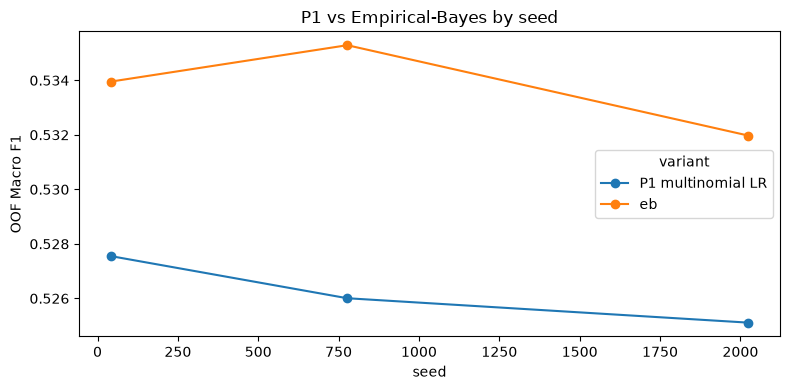

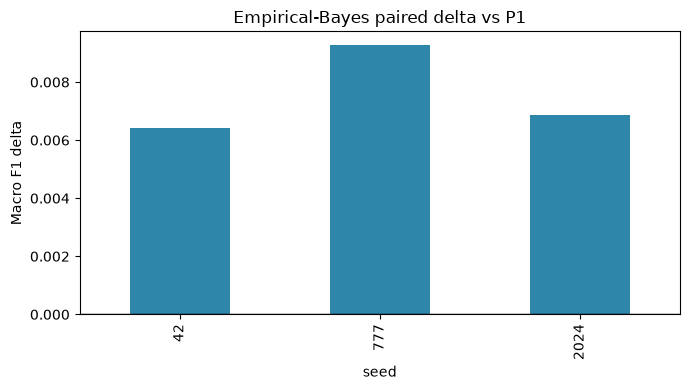

In [4]:
wide = per_seed.pivot(index='seed', columns='variant', values='oof_macro_f1').sort_index()
wide['paired_delta_vs_p1'] = wide[EB_VARIANT] - wide[P1_VARIANT]
ax = wide[[P1_VARIANT, EB_VARIANT]].plot(marker='o', figsize=(8, 4), title='P1 vs Empirical-Bayes by seed')
ax.set_ylabel('OOF Macro F1')
plt.tight_layout()
plt.savefig(RESULT / f'{RUN_ID}_3seed_macro_f1.png', dpi=160)
plt.show()

ax = wide['paired_delta_vs_p1'].plot.bar(figsize=(7, 4), color=['#2E86AB' if x > 0 else '#D1495B' for x in wide['paired_delta_vs_p1']], title='Empirical-Bayes paired delta vs P1')
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Macro F1 delta')
plt.tight_layout()
plt.savefig(RESULT / f'{RUN_ID}_3seed_paired_delta.png', dpi=160)
plt.show()
